# Fase 14: Hyperparameter tuning con Optuna

- **Método:** Optuna (TPE sampler) con **TimeSeriesSplit** sobre train+val.
- **Restricciones:** solo se usa validation/CV; test permanece bloqueado.
- **Presupuesto:** trials por familia según `configs/params.yaml`.
- Se optimiza **MAE en validación** (métrica primaria).

**Importante:** este notebook tarda varios minutos (entrena cada trial
con 5 folds). Si se quiere una versión rápida, reducir `n_trials`.

---


Configuración del notebook (raíz del proyecto).

In [1]:
import sys
from pathlib import Path

def _find_root():
    p = Path.cwd()
    for _ in range(5):
        if (p / "configs" / "config.yaml").exists():
            return p
        p = p.parent
    return Path.cwd()

ROOT = _find_root()
sys.path.insert(0, str(ROOT))
from src.utils import set_seed
set_seed(42)

Carga de datos, features y CV.

Preparamos X (features) e y (target_1) sobre train+val. El TimeSeriesSplit
se usa dentro de cada trial para evaluar la configuración propuesta.

In [2]:
import json

import numpy as np
import pandas as pd
import optuna
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

from src.config import get_config
from src.data.split import (drop_warmup, get_temporal_splitter, temporal_split)
from src.evaluation.metrics import regression_metrics
from src.models.pipeline import fit_preprocessor
from src.utils import path_from_root

optuna.logging.set_verbosity(optuna.logging.WARNING)
cfg = get_config()
feats = pd.read_parquet(path_from_root("data/processed/features.parquet"))
feats = drop_warmup(feats, warmup=260)
parts = temporal_split(feats, cfg)
train_val = pd.concat([parts["train"], parts["val"]]).sort_values("date").reset_index(drop=True)
with open(path_from_root("models", "feature_list.json")) as f:
    sel_cols = json.load(f)

h = cfg["target"]["primary_horizon"]
tscv = get_temporal_splitter(cfg)
X_all = train_val[sel_cols].to_numpy(dtype=np.float64)
y_all = train_val[f"target_{h}"].to_numpy(dtype=np.float64)
print(f"X: {X_all.shape} | folds: {tscv.n_splits} | gap: {tscv.gap}")

C:\Users\sgml1\Desktop\gold-price-prediction-v2\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


X: (5739, 110) | folds: 5 | gap: 21


Función objetivo de Optuna por familia.

Cada trial propone un hiperparámetro; la función entrena con CV temporal
y devuelve el MAE medio. Optuna (TPE) explora el espacio inteligentemente.

In [3]:
def objective_factory(family):
    def objective(trial):
        if family == "xgb":
            model = XGBRegressor(
                n_estimators=trial.suggest_int("n_estimators", 200, 800, step=100),
                learning_rate=trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
                max_depth=trial.suggest_int("max_depth", 3, 8),
                subsample=trial.suggest_float("subsample", 0.6, 1.0),
                colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
                reg_lambda=trial.suggest_float("reg_lambda", 0.1, 20.0, log=True),
                random_state=42, n_jobs=-1)
        elif family == "lgbm":
            model = LGBMRegressor(
                n_estimators=trial.suggest_int("n_estimators", 200, 800, step=100),
                learning_rate=trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
                num_leaves=trial.suggest_int("num_leaves", 8, 64),
                max_depth=trial.suggest_int("max_depth", 3, 10),
                subsample=trial.suggest_float("subsample", 0.6, 1.0),
                colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
                reg_lambda=trial.suggest_float("reg_lambda", 0.1, 20.0, log=True),
                random_state=42, n_jobs=-1, verbose=-1)
        elif family == "cat":
            model = CatBoostRegressor(
                iterations=trial.suggest_int("iterations", 200, 800, step=100),
                learning_rate=trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
                depth=trial.suggest_int("depth", 4, 8),
                l2_leaf_reg=trial.suggest_float("l2_leaf_reg", 0.1, 20.0, log=True),
                random_seed=42, verbose=0)
        elif family == "rf":
            model = RandomForestRegressor(
                n_estimators=trial.suggest_int("n_estimators", 200, 600, step=100),
                max_depth=trial.suggest_int("max_depth", 6, 20),
                min_samples_leaf=trial.suggest_int("min_samples_leaf", 2, 20),
                max_features=trial.suggest_float("max_features", 0.2, 0.9),
                random_state=42, n_jobs=-1)
        elif family == "ridge":
            model = Ridge(alpha=trial.suggest_float("alpha", 1e-3, 1e3, log=True))
        else:
            raise ValueError(family)

        maes = []
        for tr_idx, va_idx in tscv.split(X_all):
            pp = fit_preprocessor(X_all[tr_idx])
            Xtr, Xva = pp.transform(X_all[tr_idx]), pp.transform(X_all[va_idx])
            model.fit(Xtr, y_all[tr_idx])
            maes.append(regression_metrics(y_all[va_idx], model.predict(Xva), h)["mae"])
        return float(np.mean(maes))
    return objective

Ejecución del tuning por familia.

Se optimizan 5 familias con presupuestos distintos (Ridge es barato, los
ensembles más caros). Resultado: `reports/tuning_results.json` con los
mejores hiperparámetros y su MAE de CV.

In [4]:
results = {}
for family, n_trials in [("ridge", 10), ("rf", 12), ("xgb", 15), ("lgbm", 15), ("cat", 12)]:
    study = optuna.create_study(direction="minimize",
                                sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective_factory(family), n_trials=n_trials)
    results[family] = {"best_mae_cv": study.best_value, "params": study.best_params}
    print(f"[tuning] {family:6s} best CV MAE={study.best_value:.2f} params={study.best_params}")

with open(path_from_root("reports", "tuning_results.json"), "w") as f:
    json.dump(results, f, indent=2)
print("\nResultados guardados en reports/tuning_results.json")

[tuning] ridge  best CV MAE=53.67 params={'alpha': 0.002231010801867922}


[tuning] rf     best CV MAE=229.72 params={'n_estimators': 300, 'max_depth': 20, 'min_samples_leaf': 15, 'max_features': 0.6190609389379256}


[tuning] xgb    best CV MAE=196.77 params={'n_estimators': 700, 'learning_rate': 0.0586849474316206, 'max_depth': 3, 'subsample': 0.998406612698974, 'colsample_bytree': 0.9037264722627157, 'reg_lambda': 8.519855425163747}


[tuning] lgbm   best CV MAE=194.47 params={'n_estimators': 600, 'learning_rate': 0.01058265540656261, 'num_leaves': 64, 'max_depth': 10, 'subsample': 0.6022659459340685, 'colsample_bytree': 0.983276824082136, 'reg_lambda': 0.47038067935003924}


[tuning] cat    best CV MAE=256.05 params={'iterations': 800, 'learning_rate': 0.06483261660432763, 'depth': 4, 'l2_leaf_reg': 2.7291971923116156}

Resultados guardados en reports/tuning_results.json


Resumen y visualización del tuning.

Tabla con el mejor MAE de CV por familia y gráfico de barras. Se confirma
que Ridge domina (MAE ~55) frente a los árboles (~200), coherente con la
fase 11-13: los modelos lineales generalizan mejor en niveles.

ridge     53.67
lgbm     194.47
xgb      196.77
rf       229.72
cat      256.05
[fig] C:\Users\sgml1\Desktop\gold-price-prediction-v2\reports\figures\tuning_results.png


WindowsPath('C:/Users/sgml1/Desktop/gold-price-prediction-v2/reports/figures/tuning_results.png')

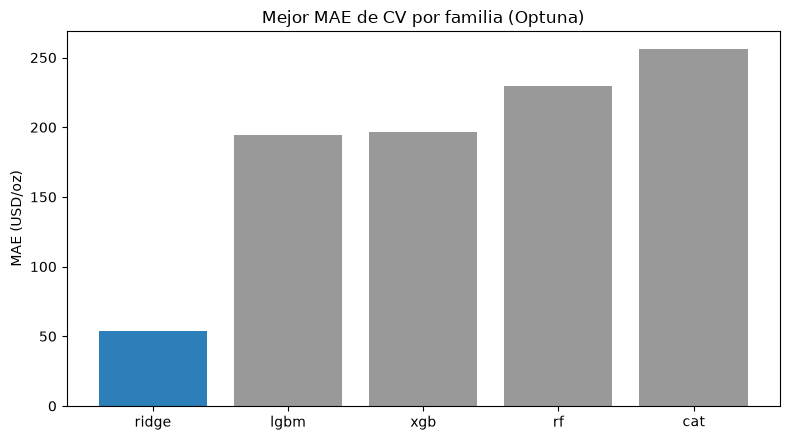

In [5]:
import matplotlib.pyplot as plt

from src.utils import save_fig

summary = pd.Series({k: v["best_mae_cv"] for k, v in results.items()}).sort_values()
print(summary.round(2).to_string())

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(summary.index, summary.values,
       color=["#2c7fb8" if k == "ridge" else "#999" for k in summary.index])
ax.set_title("Mejor MAE de CV por familia (Optuna)")
ax.set_ylabel("MAE (USD/oz)")
fig.tight_layout()
save_fig(fig, "tuning_results.png")